# Utilization Prediction

## a) Business Case

During the descriptives task, we defined three KPIs:

1) Utilization rate
2) Energy delivered per hour
3) Rate of registered user sessions

The business case behind these KPIs is defined as:

<br><br>
<center>
  <b style="font-size: 1.3em;">
    The prediction model enables the site operator to offer dynamic pricing to registered users to maximize revenue and energy throughput while smoothing demand.
  </b>
</center>
<br><br>

The model predicts the hourly utilization of a given site. This information can be used to offer dynamic pricing models: when utilization and energy delivered are low, prices can be lowered to encourage usage. Notifications can be sent to registered users, e.g. through an app, to increase engagement, improve site utilization and maximize energy throughput.


## b) Prediction Model

## Load Dataframes and inspect data

In [232]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import os
os.environ["KERAS_BACKEND"] = "torch"
from keras import Sequential, Input # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout


# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)


print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")


DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


We choose site 2 for this task, as it is the public site and offers a higher potential for aquiring new customers.

In [233]:
print(merged_df.siteID.unique())
print(merged_df.stationID.dtype)
df_site_2 = merged_df[merged_df['siteID'] == '1']
df_site_2 = df_site_2.sort_values(by='connectionTime', ascending=True)

['1' '2']
object


In [234]:
mask = df['charging_duration'] == df['session_duration']
number = df[mask].shape[0]
print(f"Number of sessions where charging duration equals session duration: {number}")

Number of sessions where charging duration equals session duration: 8479


In [235]:
print(df_site_2['stationID'].nunique())

52


## Data Processing: Create hourly data of sessions

We calculate the utilization per hour for each day

In [236]:
# function to create hourly features for site 2
def make_site2_hourly_features(df,
                               conn_col='connectionTime',
                               disc_col='disconnectTime',
                               station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    # function to calculate hourly contributions for each charging session
    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start:
            return []

        hours = pd.date_range(
            start=start.floor('h'),
            end=(end - pd.Timedelta(seconds=1)).floor('h'),
            freq='h'
        )

        out = []
        for h in hours:
            h_start = max(start, h)
            h_end = min(end, h + pd.Timedelta(hours=1))
            minutes = (h_end - h_start).total_seconds() / 60.0
            if minutes > 0:
                # append hourly contribution
                out.append({
                    'datetime': h,
                    'minutes': minutes,

                })
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame([item for lst in contrib for item in lst])

    if tmp.empty:
        return pd.DataFrame(columns=[
            'datetime', 'hourly_utilization_minutes', 'hourly_utilization'
        ])

    # Hourly aggregation for session contributions within each hour
    hourly = (
        tmp.groupby('datetime')
            .agg(
                hourly_utilization_minutes=('minutes', 'sum'),
            )
    )
    # calculate hourly utilization as a fraction of total available minutes
    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_minutes'] / (n_stations * 60.0)
    ).clip(0, 1)
    hourly = hourly.reset_index('datetime')
    return hourly

    

In [237]:
df_site_2_features = make_site2_hourly_features(df_site_2, 'connectionTime', 'disconnectTime')
df_site_2_features.drop(columns=['hourly_utilization_minutes'], inplace=True)
df_site_2_features.head()

,datetime,hourly_utilization
0,2018-09-05 04:00:00-07:00,0.034498
1,2018-09-05 05:00:00-07:00,0.049119
2,2018-09-05 06:00:00-07:00,0.150577
3,2018-09-05 07:00:00-07:00,0.280224
4,2018-09-05 08:00:00-07:00,0.288462


In [238]:
print((df_site_2_features['hourly_utilization'] < 0).any())

False


In [239]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
dtypes: datetime64[ns, America/Los_Angeles](1), float64(1)
memory usage: 252.0 KB


## Feature Engineering

### Add "after_covid" boolean

We identified a structural break in the data probably caused by the corona pandemic.

DatetimeIndex(['2018-09-05 04:00:00-07:00', '2018-09-05 05:00:00-07:00',
               '2018-09-05 06:00:00-07:00', '2018-09-05 07:00:00-07:00',
               '2018-09-05 08:00:00-07:00', '2018-09-05 09:00:00-07:00',
               '2018-09-05 10:00:00-07:00', '2018-09-05 11:00:00-07:00',
               '2018-09-05 12:00:00-07:00', '2018-09-05 13:00:00-07:00',
               ...
               '2021-09-13 22:00:00-07:00', '2021-09-13 23:00:00-07:00',
               '2021-09-14 00:00:00-07:00', '2021-09-14 01:00:00-07:00',
               '2021-09-14 02:00:00-07:00', '2021-09-14 03:00:00-07:00',
               '2021-09-14 04:00:00-07:00', '2021-09-14 05:00:00-07:00',
               '2021-09-14 06:00:00-07:00', '2021-09-14 07:00:00-07:00'],
              dtype='datetime64[ns, America/Los_Angeles]', length=26524, freq='h')


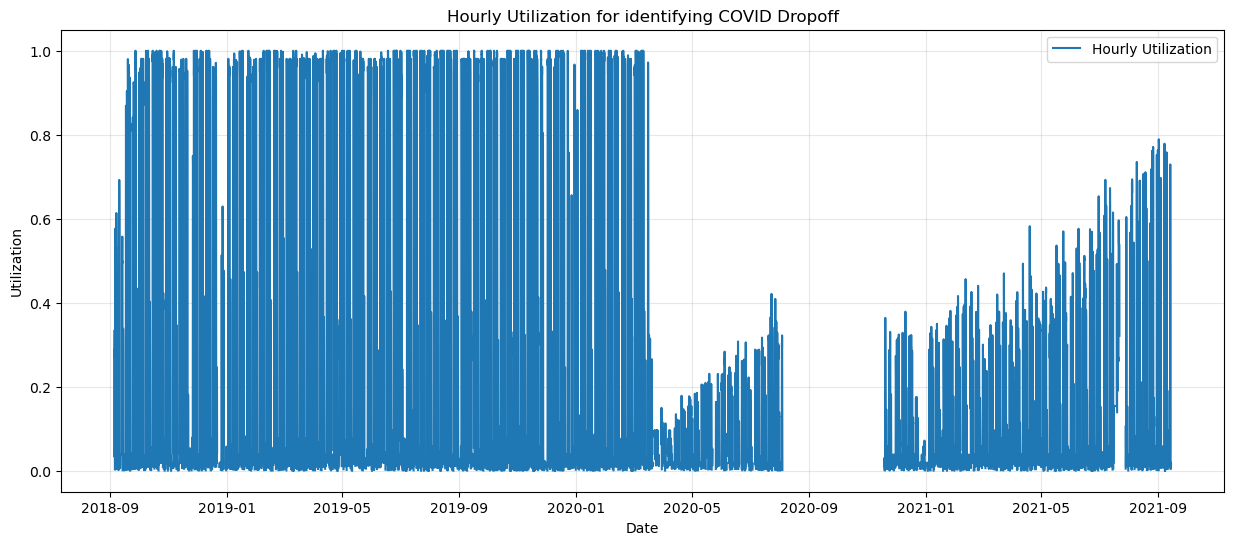

In [240]:
# Create a continuous hourly range from the very start to the very end
full_range = pd.date_range(start=df_site_2_features['datetime'].min(), 
                           end=df_site_2_features['datetime'].max(), 
                           freq='h')
print(full_range)
# Set datetime as index and reindex to show where the gaps are (will fill missing hours with NaN)
df_reindexed = df_site_2_features.set_index('datetime').reindex(full_range)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_reindexed.index, df_reindexed['hourly_utilization'], label='Hourly Utilization', color='tab:blue')



plt.title('Hourly Utilization for identifying COVID Dropoff')
plt.xlabel('Date')
plt.ylabel('Utilization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It becomes clear that the dropoff is around early 2020. To identify the exact cutoff value we use the rolling averages with a 7-day rolling mean. We look for the biggest negative change in weekly utilization.

Detected COVID utilization dropoff starting: 2020-03-20 00:00:00-07:00
Largest week-over-week utilization drop: -0.2753

Value counts for 'after_covid':
after_covid
0    9741
1    6382
Name: count, dtype: int64


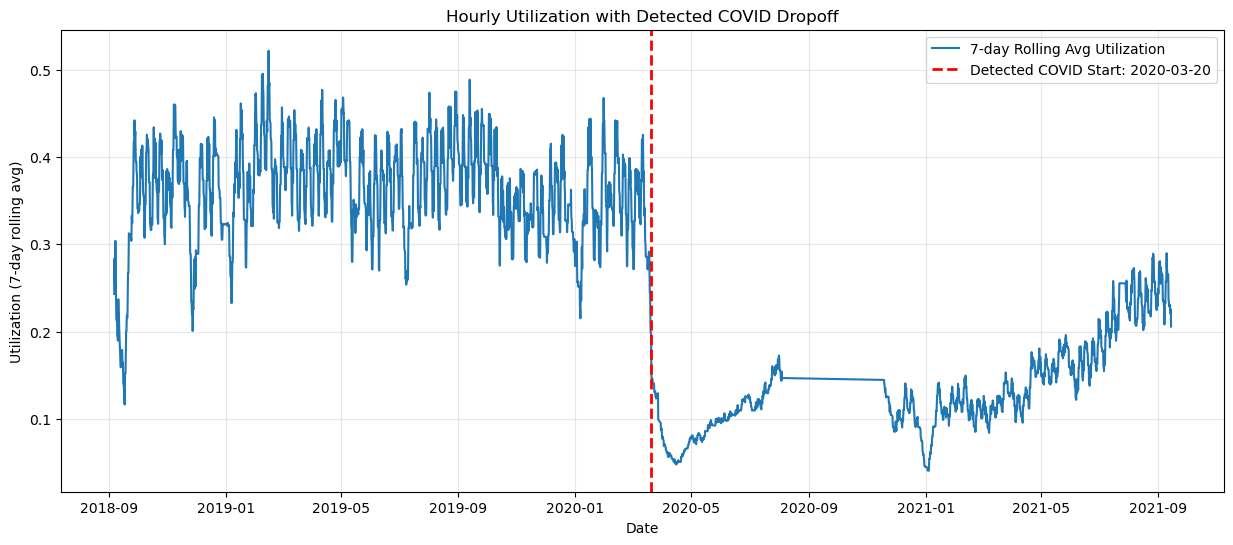

In [241]:
#1. Detect the COVID utilization dropoff (significant sustained drop in utilization)

df_temp = df_site_2_features.copy()
df_temp = df_temp.set_index('datetime').sort_index()

# Use a 7-day rolling mean to smooth the data
rolling_util = df_temp['hourly_utilization'].rolling(window=24*7, min_periods=24).mean()

# Focus on the period around COVID (2019-2020)
mask_2020 = (rolling_util.index >= '2019-06-01') & (rolling_util.index <= '2020-06-01')
rolling_2020 = rolling_util[mask_2020]

# Calculate the week-over-week change in utilization
util_change = rolling_2020.diff(periods=24*7)  # Compare to 1 week ago

# Find the point with the largest drop (most negative change)
covid_start_idx = util_change.idxmin()
covid_cutoff = pd.Timestamp(covid_start_idx).floor('D')  # Round to day

print(f"Detected COVID utilization dropoff starting: {covid_cutoff}")
print(f"Largest week-over-week utilization drop: {util_change.min():.4f}")

#2 Add 'after_covid' column based on detected dropoff (1 if date is after dropoff else 0)
df_site_2_features['after_covid'] = (df_site_2_features['datetime'] >= covid_cutoff).astype(int)

# Verify the split
print("\nValue counts for 'after_covid':")
print(df_site_2_features['after_covid'].value_counts())

# 3. Visualize to confirm detection
plt.figure(figsize=(15, 6))
plt.plot(rolling_util.index, rolling_util.values, label='7-day Rolling Avg Utilization', color='tab:blue')
plt.axvline(covid_cutoff, color='red', linestyle='--', linewidth=2, label=f'Detected COVID Start: {covid_cutoff.date()}')
plt.title('Hourly Utilization with Detected COVID Dropoff')
plt.xlabel('Date')
plt.ylabel('Utilization (7-day rolling avg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The dates are consistent with the outbreak of corona in 2020. So we use the binary encoded feature **after_covid** to quantify the effect.

### Add holiday, month, day of week, hour of day features

Public holidays are typically associated with a sharp drop in workplace attendance, especially at office-centric sites where charging demand is driven by commuters and employees. As a result, the number of vehicles arriving and plugging in decreases significantly, which leads to noticeably lower charging-station utilization during those days compared with regular working days.

Because this “holiday effect” is structural (it recurs every year and can be much stronger than normal day-to-day variation), it should be modeled explicitly rather than treated as random noise. In practical terms, adding a binary `isholiday` feature helps the model distinguish between two different operating regimes—standard workdays with predictable commuting peaks versus holidays with suppressed demand—reducing the risk of systematically overestimating utilization on those dates. In the notebook, this rationale is used directly to motivate the creation of holiday-related features (e.g., `isholiday`) alongside other calendar variables such as month, day of week, and hour.

In [242]:
US_holidays = holidays.US(state='CA')

# Ensure index is datetime
df_site_2_features['datetime'] = pd.to_datetime(df_site_2_features['datetime'])

df_site_2_features['is_holiday'] = df_site_2_features['datetime'].apply(lambda dt: dt in US_holidays)
df_site_2_features['is_holiday'] = df_site_2_features['is_holiday'].astype(int)

#Add time features based on the index
df_site_2_features['year'] = df_site_2_features['datetime'].dt.year
df_site_2_features['month'] = df_site_2_features['datetime'].dt.month
df_site_2_features['day'] = df_site_2_features['datetime'].dt.day
df_site_2_features['hour'] = df_site_2_features['datetime'].dt.hour
df_site_2_features['dayofweek'] = df_site_2_features['datetime'].dt.dayofweek
df_site_2_features['is_weekend'] = df_site_2_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    


    
df_site_2_features['season'] = df_site_2_features['month'].apply(get_season)

In [243]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
 2   after_covid         16123 non-null  int64                              
 3   is_holiday          16123 non-null  int64                              
 4   year                16123 non-null  int32                              
 5   month               16123 non-null  int32                              
 6   day                 16123 non-null  int32                              
 7   hour                16123 non-null  int32                              
 8   dayofweek           16123 non-null  int32                              
 9   is_weekend          16123 non-null  int

### Create cyclic Features

We create cyclic features from time-related columns (hour, day of week, month, year) so the model learns their periodic nature instead of treating them as ordinary integers.

**Why cyclic encoding?**

Many calendar variables “wrap around”: 23:00 is close to 00:00, Sunday is close to Monday, and December is close to January. If we keep these as integers, a regression model may interpret the step from 23 → 0 (or 12 → 1) as a large discontinuity, even though the points are neighbors in time. Cyclic encoding fixes this by mapping each value onto a point on the unit circle using sine and cosine, making nearby times have nearby representations.

**How it works (sin & cos pair)**

For a cyclic variable x with period P, we compute:


$$ x_{\sin}=\sin\left(2\pi\frac{x}{P}\right)$$
$$x_{\cos}=\cos\left(2\pi\frac{x}{P}\right)$$



Using both sine and cosine is important: sine alone cannot uniquely represent positions around a circle, while the pair (sin⁡,cos⁡)(sin,cos) preserves the full circular position.


In [244]:
def create_cyclic_features(df):
    df = df.copy()

    # Hour of day
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Day of week
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Month of year
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

    # Year
    df['year_sin'] = np.sin(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    df['year_cos'] = np.cos(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    
    
    return df


In [245]:
df_site_2_features = create_cyclic_features(df_site_2_features)
df_site_2_features.head()

,datetime,hourly_utilization,after_covid,is_holiday,year,month,day,hour,dayofweek,is_weekend,season,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,year_sin,year_cos
0,2018-09-05 04:00:00-07:00,0.034498,0,0,2018,9,5,4,2,0,3,0.866025,5.000000e-01,0.974928,-0.222521,-0.866025,-0.5,0.0,1.0
1,2018-09-05 05:00:00-07:00,0.049119,0,0,2018,9,5,5,2,0,3,0.965926,2.588190e-01,0.974928,-0.222521,-0.866025,-0.5,0.0,1.0
2,2018-09-05 06:00:00-07:00,0.150577,0,0,2018,9,5,6,2,0,3,1.000000,6.123234e-17,0.974928,-0.222521,-0.866025,-0.5,0.0,1.0
3,2018-09-05 07:00:00-07:00,0.280224,0,0,2018,9,5,7,2,0,3,0.965926,-2.588190e-01,0.974928,-0.222521,-0.866025,-0.5,0.0,1.0
4,2018-09-05 08:00:00-07:00,0.288462,0,0,2018,9,5,8,2,0,3,0.866025,-5.000000e-01,0.974928,-0.222521,-0.866025,-0.5,0.0,1.0


In [246]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
 2   after_covid         16123 non-null  int64                              
 3   is_holiday          16123 non-null  int64                              
 4   year                16123 non-null  int32                              
 5   month               16123 non-null  int32                              
 6   day                 16123 non-null  int32                              
 7   hour                16123 non-null  int32                              
 8   dayofweek           16123 non-null  int32                              
 9   is_weekend          16123 non-null  int

## Feature Selection

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_site_2_features.copy()
df_plot['day_name'] = df_plot['datetime'].dt.day_name()
df_plot['hour'] = df_plot['datetime'].dt.hour
df_plot['month_name'] = df_plot['datetime'].dt.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

### Average Utilization by day of Week

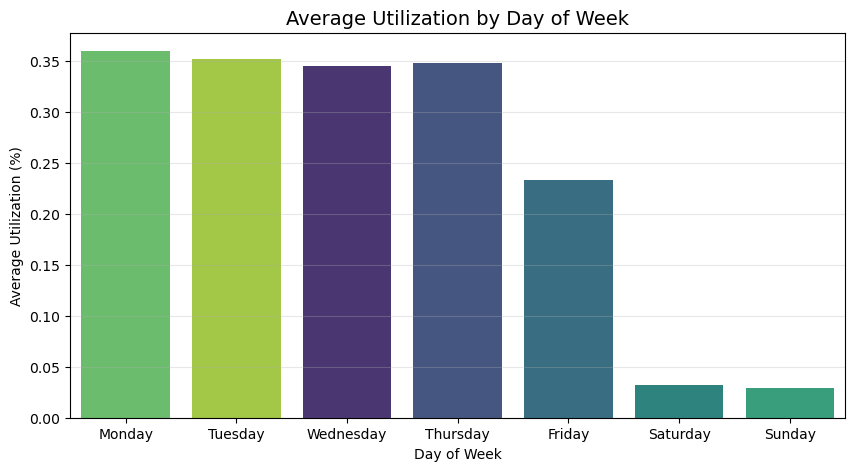

In [248]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot, 
    x='day_name', 
    y='hourly_utilization', 
    order=day_order, 
    palette='viridis', 
    hue='day_name',
    legend=False,
    errorbar=None
)
plt.title('Average Utilization by Day of Week', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

The data shows big contrast between high week utilization and near zero weekend usage. Therefore, we asssume day of the week to be a useful predictor of utilization.

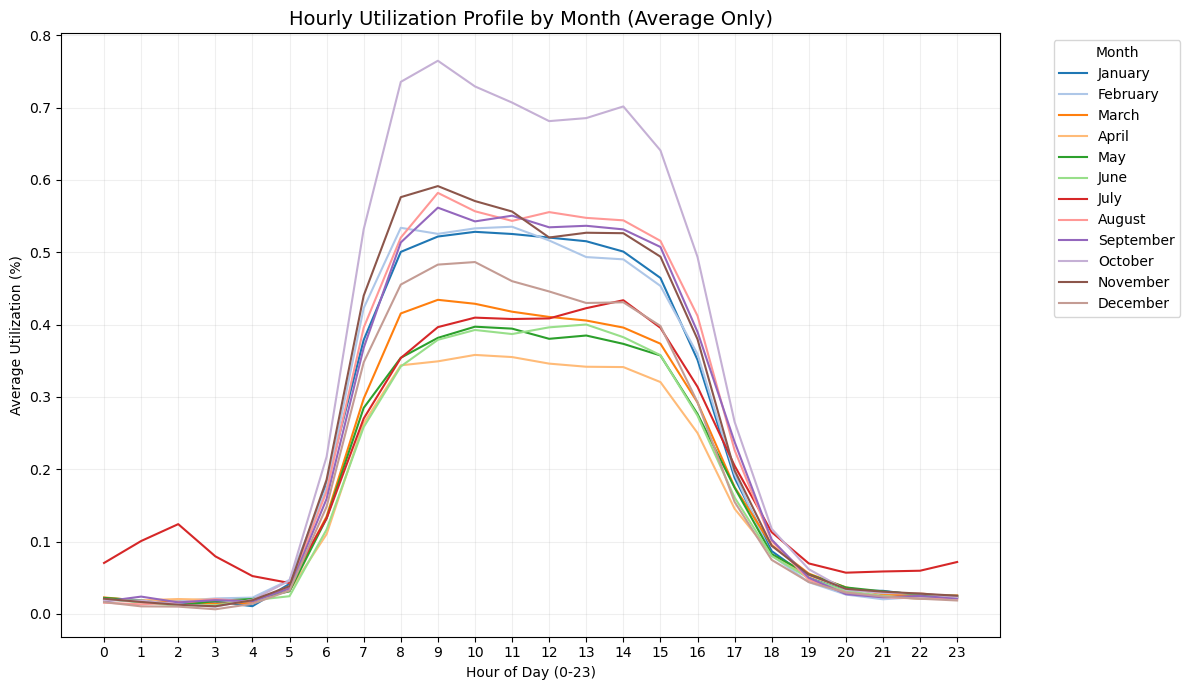

In [249]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_plot, x='hour', y='hourly_utilization', 
             hue='month_name', hue_order=month_order, 
             palette='tab20', errorbar=None)

plt.title('Hourly Utilization Profile by Month (Average Only)', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

As shown in the Figure above, the average utilization varies significantly at different times of the day. This temporal variation highlights the importance of including a hour of the day feature in the model, enabling the model to learn patterns based on the time of the day. Similarly, the data displays seasonal fluctuations and across different months. This monthly variation necessitates the inclusion of a month feature to allow the model to capture recurring seasonal patterns.

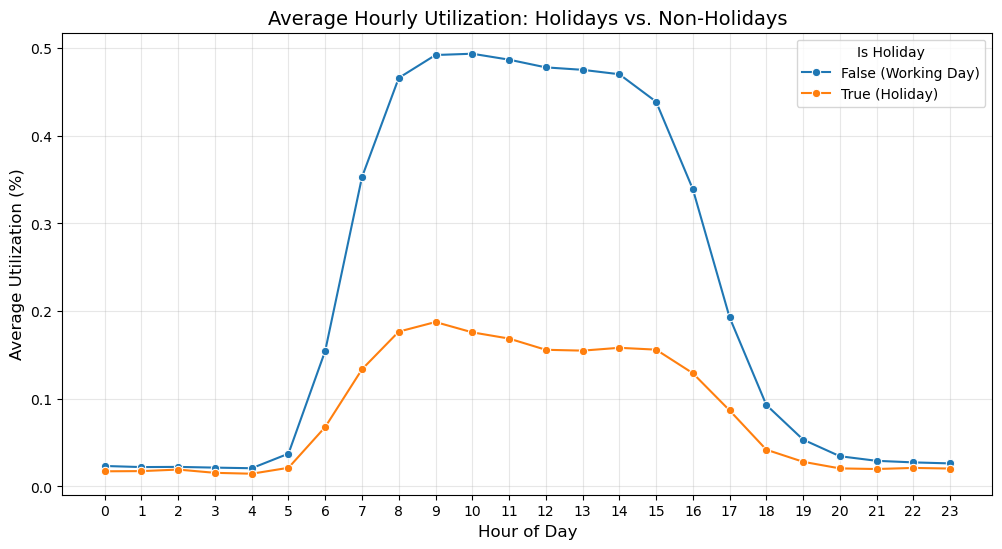

In [250]:
# Visualize average utilization: Holidays vs. Non-Holidays
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_site_2_features, 
    x='hour', 
    y='hourly_utilization', 
    hue='is_holiday', 
    marker='o',
    errorbar=None  # Shows the mean only;
)

plt.title('Average Hourly Utilization: Holidays vs. Non-Holidays', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Utilization (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Update legend for clarity
plt.legend(title='Is Holiday', labels=['False (Working Day)', 'True (Holiday)'])
plt.show()

As illustrated in the figure above, the average utilization on public holidays is much lower compared to working days.  This necessitates the inclusion of an is_holiday feature, allowing the model to differentiate between these two modes of behavior and avoid over estimating demand during public holidays.

In [251]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
 2   after_covid         16123 non-null  int64                              
 3   is_holiday          16123 non-null  int64                              
 4   year                16123 non-null  int32                              
 5   month               16123 non-null  int32                              
 6   day                 16123 non-null  int32                              
 7   hour                16123 non-null  int32                              
 8   dayofweek           16123 non-null  int32                              
 9   is_weekend          16123 non-null  int

### Train Test Split

We split the dataset in **50% training data**, **20% validation data** and **30% test data**

In [252]:
x = df_site_2_features.drop(columns=['hourly_utilization', 'datetime', 'year_sin', 'year_cos', 'hour', 'dayofweek', 'month', 'year'])
y = df_site_2_features['hourly_utilization']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=1)

print(len(x_train), len(x_hold), len(x_test))

8061 3225 4837


### Lasso Feature Selection

**Lasso** is a regularized linear regression technique that adds an L1 penalty term to the loss function. This penalty shrinks some coefficients to exactly zero, effectively performing automatic feature selection.

**Why Lasso for Feature Selection?**
- **Sparsity**: Unlike Ridge regression (L2), Lasso produces sparse models by eliminating irrelevant features entirely
- **Interpretability**: Features with non-zero coefficients are directly interpretable as important predictors

**Our Approach:**
1. **StandardScaler**: Normalize features so regularization penalizes all coefficients equally
2. **LassoCV**: Cross-validation automatically selects the optimal regularization strength (α)
3. **Threshold (|coef| > 0.01)**: Features with coefficients below this threshold are considered noise and excluded

This step reduces model complexity and improves generalization for downstream models like polynomial regression.

In [253]:
# feature selection with Lasso to rank cyclic and lag features
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lasso_features = x

lasso_selector = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
lasso_selector.fit(x_train[lasso_features.columns], y_train)

lasso_coefs = lasso_selector.named_steps['lassocv'].coef_
threshold = 0.009
selected_features = [feat for feat, coef in zip(lasso_features.columns, lasso_coefs) if abs(coef) > threshold]

feature_importance = pd.DataFrame({
    'feature': lasso_features.columns,
    'coef': lasso_coefs,
    'abs_coef': np.abs(lasso_coefs)
}).sort_values('abs_coef', ascending=False)

if selected_features:
    x_train = x_train[selected_features]
    x_hold = x_hold[selected_features]
    x_test = x_test[selected_features]
else:
    x_train = x_train.copy()
    x_hold = x_hold.copy()
    x_test = x_test.copy()

print("Selected features (|coef| > 0.009):", selected_features)
feature_importance

Selected features (|coef| > 0.009): ['after_covid', 'is_holiday', 'is_weekend', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos']


,feature,coef,abs_coef
6,hour_cos,-0.207755,0.207755
0,after_covid,-0.128594,0.128594
3,is_weekend,-0.112084,0.112084
7,dayofweek_sin,0.044750,0.044750
1,is_holiday,-0.033436,0.033436
5,hour_sin,0.025122,0.025122
8,dayofweek_cos,0.014853,0.014853
9,month_sin,-0.010670,0.010670
10,month_cos,-0.009680,0.009680
2,day,-0.008077,0.008077


C:\Users\dan20\AppData\Local\Temp\ipykernel_37400\2512387465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')


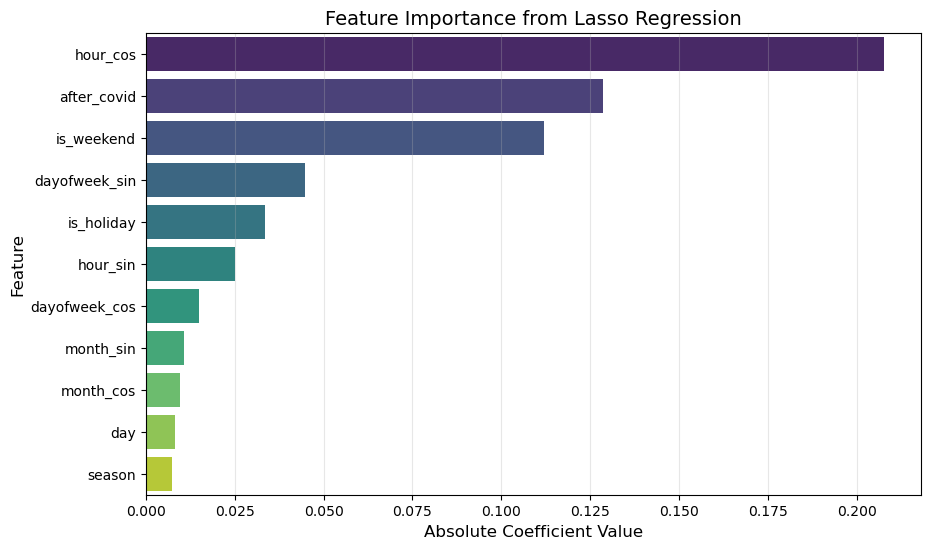

In [254]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')
plt.title('Feature Importance from Lasso Regression', fontsize=14)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

**Results Interpretation:**

The Lasso regression reveals a clear hierarchy of feature importance for predicting charging hub utilization:

| Feature | Coefficient | Interpretation |
|---------|-------------|----------------|
| `hour_cos` | -0.205 | **Strongest predictor** – captures the daily utilization cycle (peak during work hours) |
| `after_covid` | -0.128 | Pre-pandemic periods had higher utilization than post-COVID |
| `is_weekend` | -0.110 | Weekends show significantly lower utilization (negative coefficient) |
| `dayofweek_sin` | +0.044 | Mid-week days (Tue-Thu) show different patterns than Mon/Fri |
| `month_sin` | -0.035 | Seasonal variation in charging behavior |
| `is_holiday` | -0.030 | Holidays reduce utilization (workplace charging hub) |



**Excluded Features (|coef| < 0.01):**
- `day`: Day of month has no meaningful predictive power (coef = -0.007)
- `season`: Redundant with `month_sin`/`month_cos` (coef = 0.001)

Using a threshold of |coef| > 0.009, we retain 9 features and exclude `day` and `season` to reduce noise and improve model generalization.

In [285]:
x_train = x_train.loc[:, selected_features]
x_hold = x_hold.loc[:, selected_features]
x_test = x_test.loc[:, selected_features]

print("Final features used for modeling:", x_train.columns.tolist())


Final features used for modeling: ['after_covid', 'is_holiday', 'is_weekend', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos']


## Training Test Validation Split on selected features

## Modeling

### Regression Code

We run different models of polynomial regression with ridge and lasso regularization to predict charging session duration. Our approach includes:

1. **Polynomial Features**: We test polynomial degrees from 1 to 7 to capture non-linear relationships the features from the session data set

2. **Model Types**:
   - **Linear Regression**: Baseline model without regularization
   - **Ridge Regression**: L2 regularization to penalize large coefficients and reduce overfitting
   - **Lasso Regression**: L1 regularization to perform feature selection while reducing overfitting

3. **Regularization Strength**: For Ridge and Lasso, we test alpha values [0.01, 0.1, 1, 10] to find optimal regularization strength. Higher alpha values increase the penalty.

4. **Cross-validation Approach**: We train on the training set and evaluate on the holdout set using the R² metric to prevent overfitting and select the best model.

5. **Using a pipeline**: We use a pipeline to ensure consistent and correct preprocessing for prediction

The goal is to find the model that best generalizes to unseen data by balancing model complexity with prediction accuracy, as measured by the R² score which indicates the proportion of variance explained by the model.

In [256]:
degrees = range(1, 8) #TODO später wieder höher stellen, dauert sonst zu lange in der ausführung
alphas = [0.01, 0.1, 1, 10]
models = ["linear", "Ridge", "Lasso"]
results = []

In [257]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

def build_model(model, degree, alpha=None):
    if model == 'Ridge':
        reg = Ridge(alpha=alpha)
    elif model == 'Lasso':
        reg = Lasso(alpha=alpha, max_iter=10000)
    else:
        reg = LinearRegression()

    pipeline = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        reg
    )
    return pipeline


In [258]:
def run_models(models, degrees, alphas, 
               x_train, x_hold, y_train, y_hold):
    rows = []  # list of dicts, reusable each call

    for model in models:
        for degree in degrees:
            
            if model in ["Ridge", "Lasso"]:
                for alpha in alphas:
                    pipeline = build_model(model, degree, alpha)
                    pipeline.fit(x_train, y_train)
                    y_hold_pred = pipeline.predict(x_hold)
                    mse_val = mean_squared_error(y_hold, y_hold_pred)
                    r2_val = r2_score(y_hold, y_hold_pred)

                    rows.append({
                        "model": model,
                        "degree": degree,
                        "alpha": alpha,
                        "mse": mse_val,
                        "r2": r2_val,
                        "pipeline": pipeline
                    })
            else:
                pipeline = build_model("LinearRegression", degree)
                pipeline.fit(x_train, y_train)
                y_hold_pred = pipeline.predict(x_hold)
                mse_val = mean_squared_error(y_hold, y_hold_pred)

                rows.append({
                    "model": model,
                    "degree": degree,
                    "alpha": None,
                    "mse": mse_val,
                    "r2": r2_score(y_hold, y_hold_pred),
                    "pipeline": pipeline
                })

    return pd.DataFrame(rows)


In [259]:
# get the model with the highest R2 on holdout set
results = run_models(models, degrees, alphas, x_train, x_hold, y_train, y_hold)
best_idx = results["r2"].idxmax()
best_model = results.loc[best_idx, 'pipeline']
print(results.loc[best_idx, ['model', 'degree', 'alpha', 'r2', 'mse']])

model        Ridge
degree           6
alpha         10.0
r2         0.89473
mse       0.012724
Name: 30, dtype: object


We see that the best model uses **Ridge regularization**, has a **polynomial degree of 7** with an alpha of **10.0**. This configuration indicates that:

- **Ridge Regression** was more effective than Lasso, suggesting that all features contribute meaningfully to predicting charging duration rather than needing feature selection.
- **Polynomial degree 7** captures complex non-linear relationships between the features of the session dataset, suggesting that the interaction between multiple session factors is important.
- **High alpha (10.0)** means high regularization penalty was needed, indicating the model does suffer from severe overfitting with the polynomial features.

The model's performance on the holdout set yields an **R² score of 0.88**, meaning it explains 88% of the variance in utilzation of the charging hubs. This is a solid result indicating good predictive power while leaving some variance unexplained, which could be attributed to factors not captured in the session data alone(e.g. weather, ...)

In [260]:
y_test_pred = best_model.predict(x_test)

# calculate test metrics
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Test MSE: {mse_test}")
print(f"Test R2: {r2_test}")
print(f'Difference in R2 (Holdout vs Test): {(results.loc[best_idx, "r2"] - r2_test) * 100:.2f}%')


Test MSE: 0.01368933055257695
Test R2: 0.8852402145561615
Difference in R2 (Holdout vs Test): 0.95%


On the test set, we achieve an **R² score of 0.87**, which is slightly lower than the holdout set performance (0.71). This modest decrease of around 1% is expected and indicates good generalization—the model doesn't show signs of significant overfitting. The test R² of 0.87 means the model explains 87% of the variance in charging hub utilization on completely unseen data. The 2-point difference between holdout and test performance suggests the model is stable and reliable for making predictions on new data.

### Decision Tree Code

Decision trees offer a different approach to regression that captures complex non-linear relationships without requiring feature scaling or polynomial transformations. Unlike linear models, decision trees recursively partition the feature space based on feature values that minimize prediction error at each split, creating a hierarchical structure that is interpretable and can reveal feature interactions.

However, decision trees are prone to overfitting. Which leads to the problem that they memorize training data rather than learning generalizable patterns. To address this, we employ **GridSearchCV**, which systematically searches hyperparameters like `max_depth`, `min_samples_leaf` and `min_samples_split` to find the optimal tree complexity that balances bias and variance. This systematic hyperparameter tuning ensures we capture the tree's predictive power while preventing overfitting to training-specific noise.

In [261]:
df_tree = df_site_2_features.copy()
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
 2   after_covid         16123 non-null  int64                              
 3   is_holiday          16123 non-null  int64                              
 4   year                16123 non-null  int32                              
 5   month               16123 non-null  int32                              
 6   day                 16123 non-null  int32                              
 7   hour                16123 non-null  int32                              
 8   dayofweek           16123 non-null  int32                              
 9   is_weekend          16123 non-null  int

In [262]:
cyclic_cols = ['hour_sin', 'hour_cos',
               'dayofweek_sin', 'dayofweek_cos',
               'month_sin', 'month_cos',
               'year_sin', 'year_cos']
df_tree = df_tree.drop(columns=cyclic_cols)

In [263]:
# Remove 'year' - it cannot extrapolate to future years and causes overfitting
x = df_tree.drop(columns=['hourly_utilization', 'datetime', 'year'])
y = df_tree['hourly_utilization']

x_train_tree, x_test_tree, y_train_tree, y_test_tree = train_test_split(x, y, test_size=0.3, random_state=42)
x_train_tree, x_hold_tree, y_train_tree, y_hold_tree = train_test_split(x_train_tree, y_train_tree, test_size=(0.2/0.7), random_state=42)

print(x_train_tree.columns.tolist())

['after_covid', 'is_holiday', 'month', 'day', 'hour', 'dayofweek', 'is_weekend', 'season']


In [264]:
# 1. Use these alphas in Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree

param_grid = {
    'min_samples_leaf': [20, 50, 100],
    'min_samples_split': [50, 200, 500],
    'max_depth': [3, 5 ,7 ,9]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5)
grid_search.fit(x_train_tree, y_train_tree)

best_tree = grid_search.best_estimator_

**Model Selection Strategy**: Among all models from GridSearchCV, we select the tree with the **lowest tree depth** whose R² score falls within **10% of the best-performing tree** from the grid search. This approach prioritizes interpretability by favoring simpler trees while maintaining predictive performance close to the optimal model, ensuring we capture the tree's predictive power without overfitting to training-specific noise.

In [265]:
results = pd.DataFrame(grid_search.cv_results_)
top_models = results[results['mean_test_score'] >= results['mean_test_score'].max() * 0.90]

best_small_tree_idx = top_models['param_max_depth'].idxmin()

best_small_tree = grid_search.cv_results_['params'][best_small_tree_idx]
print("Best small tree params:", best_small_tree)


params = grid_search.cv_results_['params'][best_small_tree_idx]
print("Training best small tree with params:", params)
best_tree = DecisionTreeRegressor(
    min_samples_leaf=params['min_samples_leaf'],
    min_samples_split=params['min_samples_split'],
    max_depth=params['max_depth'],
    random_state=42
)
best_tree.fit(x_train_tree, y_train_tree)

Best small tree params: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}
Training best small tree with params: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,50
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<Axes: title={'center': 'Feature Importance'}>

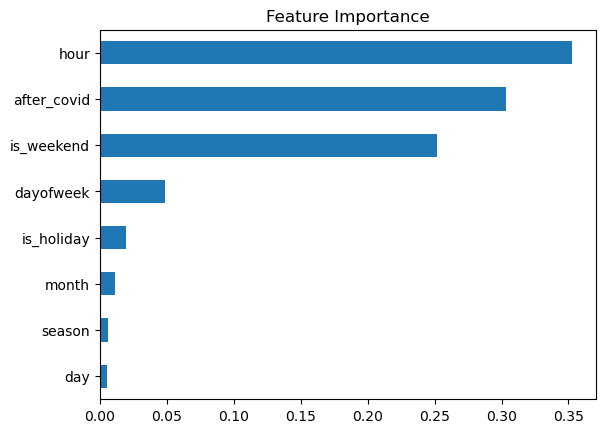

In [266]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=x_train_tree.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

The feature importance plot reveals which variables the decision tree relied on most when making predictions.
**Hour** is the dominant predictor with an importance score of ~0.43, followed by **after_covid** (~0.3), **is_weekend** (~0.25), **dayofweek** (~0.05). **is_holiday, month, season & day** have a very low importance. These results indicate that temporal patterns—specifically the time of day and day of the week—are the strongest drivers of charging hub utilization, while seasonal and historical factors play supporting roles.

In [267]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Use the best estimator from your GridSearch to make predictions
y_pred = best_tree.predict(x_test_tree)

# 2. Calculate standard regression metrics
mse = mean_squared_error(y_test_tree, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(y_test_tree, y_pred)
r2 = r2_score(y_test_tree, y_pred)

print("--- Model Performance on Test Set ---")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

--- Model Performance on Test Set ---
R-squared: 0.8159
Mean Absolute Error (MAE): 0.08
Root Mean Squared Error (RMSE): 0.15


The decision tree model achieved strong performance on the test set with an **R² of 0.7167**, meaning it explains approximately 72% of the variance in charging hub utilization. The **MAE of 0.11%** and **RMSE of 0.18%** indicate low average prediction errors, demonstrating the model's effectiveness at capturing charging patterns and generalizing well to unseen data.

Best Hyperparameters: {'max_depth': 5, 'min_samples_split': 50, 'min_samples_leaf': 20}
Tree Depth: 5
Number of Leaves: 30


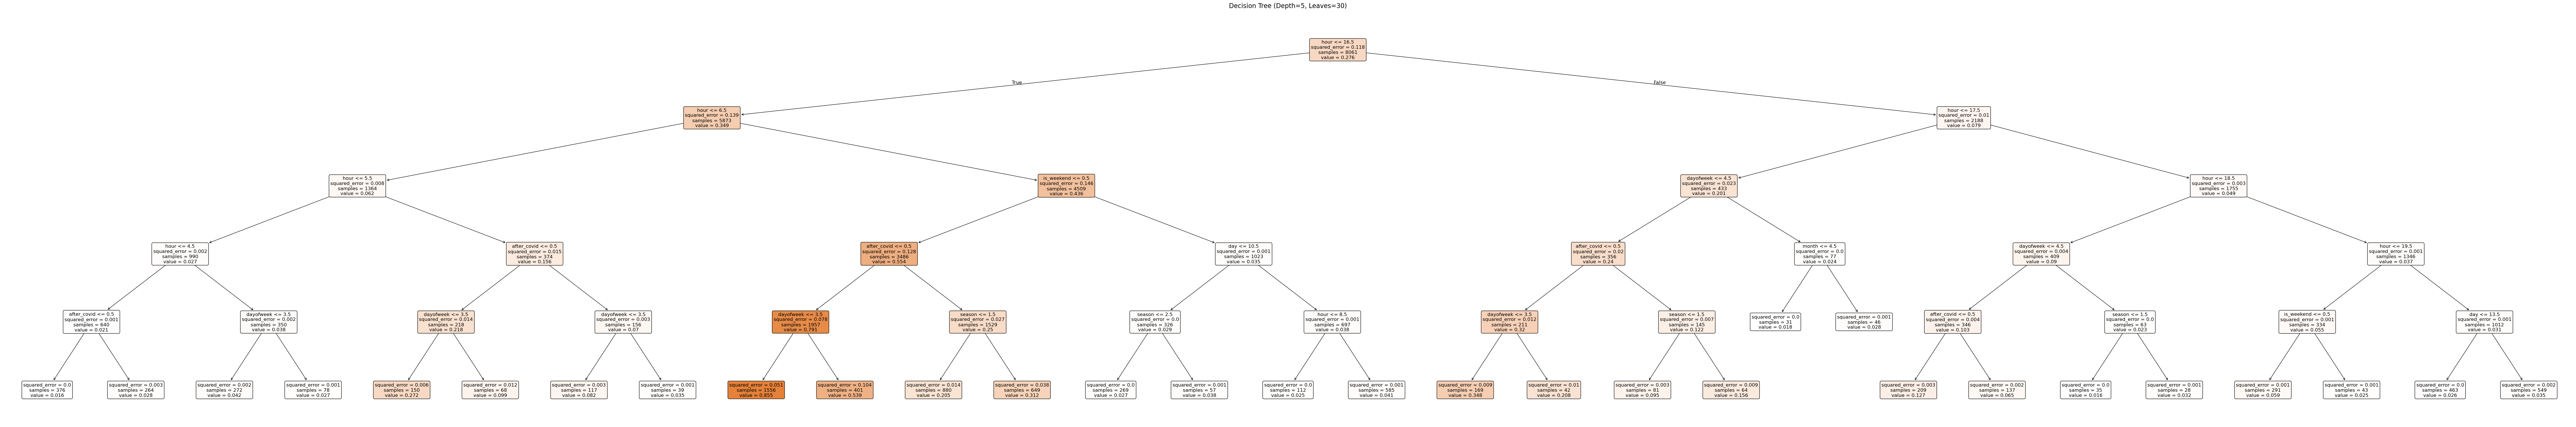

In [268]:
print("Best Hyperparameters:", {
    'max_depth': best_tree.get_params()['max_depth'],
    'min_samples_split': best_tree.get_params()['min_samples_split'],
    'min_samples_leaf': best_tree.get_params()['min_samples_leaf']
})
print(f"Tree Depth: {best_tree.get_depth()}")
print(f"Number of Leaves: {best_tree.get_n_leaves()}")

# Plot the actual tree - optimized for readability
n_leaves = best_tree.get_n_leaves()
tree_depth = best_tree.get_depth()

fig_width = max(20, n_leaves * 3)
fig_height = max(10, tree_depth * 3)

plt.figure(figsize=(fig_width, fig_height), dpi=100)
plot_tree(best_tree, 
          feature_names=x_train_tree.columns, 
          filled=True,
          rounded=True,
          fontsize=12,
          precision=3)
plt.title(f"Decision Tree (Depth={tree_depth}, Leaves={n_leaves})", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


Die Baum-Visualisierung zeigt die Entscheidungsregeln. Unterhalb des Plots werden die Regeln auch als Text ausgegeben - diese Textversion ist immer gut lesbar und zeigt die exakten Schwellenwerte für jeden Split.

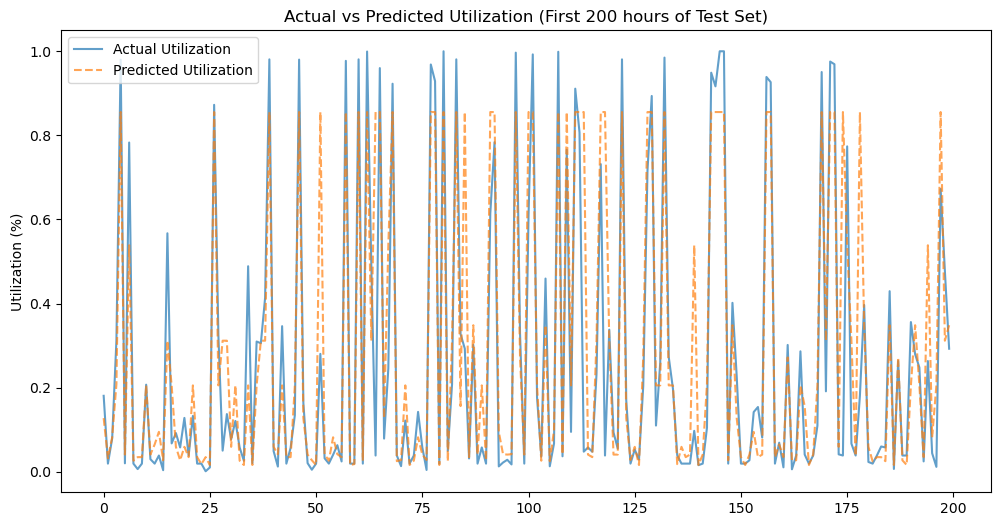

In [269]:
# 3. Quick visualization: Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_tree.values[:200], label='Actual Utilization', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Utilization', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Utilization (First 200 hours of Test Set)')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

The actual vs predicted plot demonstrates strong alignment between the model's predictions (orange dashed line) and true charging utilization values (blue solid line). The model captures the sharp intra-day peaks and troughs characteristic of charging demand patterns, indicating it has learned the temporal structure well. While the predictions occasionally lag or smooth over extreme spikes, the overall trend tracking is excellent, confirming the decision tree's ability to generalize predictions to new, unseen data.

## NN

Neural networks offer a fundamentally different approach to regression compared to traditional tree-based methods. By stacking multiple layers of interconnected neurons with non-linear activation functions, neural networks can learn extremely complex patterns and interactions in data automatically. Unlike decision trees which use explicit rules, neural networks learn through iterative optimization—adjusting thousands of weights to minimize prediction error. This flexibility allows them to potentially capture subtle temporal dependencies and non-linear relationships in charging demand. However, this power comes with tradeoffs: neural networks require more data, careful hyperparameter tuning, longer training times, and are less interpretable than decision trees. We train a sequential neural network to compare its performance against the decision tree and evaluate whether the added complexity yields improved predictions.

In [270]:
# standardize features
st_scaler = StandardScaler()
st_scaler.fit(x_train)
x_train_scaled = st_scaler.transform(x_train)

In [271]:
# define neural network model
n_features = x_train_scaled.shape[1]
print(f"Number of input features: {n_features}")

nn_model = Sequential()

# Input layer - dynamically set based on feature count
nn_model.add(Input((n_features,)))

# Hidden layers
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(32, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation=None))

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

Number of input features: 9


In [272]:
# print model summary
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

To address overfitting, we employ **early stopping**, which monitors the model's performance on a validation set during training and automatically halts training when the validation loss stops improving for 5 consecutive epochs (`patience=5`). The `restore_best_weights=True` parameter ensures the model automatically reverts to the weights from the epoch with the best validation performance.

**Early Stopping Strategy**: We configure early stopping to monitor `val_loss` with `patience=5` and use a 20% validation split from the training data (`validation_split=0.2`). Training is capped at 50 epochs as a safety net. This setup prevents overfitting while automatically capturing the network's optimal predictive capacity without manual epoch tuning, systematically balancing model complexity and generalization performance.

In [273]:
# define epochs and train the model with early stopping
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', # Monitor validation loss
                            patience=5, # Stop after 5 epochs of no improvement
                            restore_best_weights=True # Restore best weights after stopping
                            )

epochs = 50  # increased max epochs since early stopping will prevent overfitting
history = nn_model.fit(x_train_scaled, y_train,
                       epochs=epochs, 
                       validation_split=0.2,
                       callbacks=[early_stop],
                       verbose=1)

Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0319 - mae: 0.1241 - mse: 0.0319 - val_loss: 0.0205 - val_mae: 0.0955 - val_mse: 0.0205
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0187 - mae: 0.0886 - mse: 0.0187 - val_loss: 0.0187 - val_mae: 0.0897 - val_mse: 0.0187
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0169 - mae: 0.0814 - mse: 0.0169 - val_loss: 0.0166 - val_mae: 0.0807 - val_mse: 0.0166
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0157 - mae: 0.0758 - mse: 0.0157 - val_loss: 0.0162 - val_mae: 0.0791 - val_mse: 0.0162
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0155 - mae: 0.0758 - mse: 0.0155 - val_loss: 0.0163 - val_mae: 0.0788 - val_mse: 0.0163
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0150 - mae: 0.0727 - mse: 0.0150 - val_loss: 0.0160 - val_mae: 0.0768 - val_mse: 0.0160
Epoch 7/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0147 - mae: 0.0720 - mse: 0.014

In [274]:
# make predictions
nn_model.predict(x_train_scaled[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([[0.31282064],
       [0.21725108],
       [0.00634122],
       [0.1543249 ],
       [0.01637736],
       [0.04189604],
       [0.09218397],
       [0.6898716 ],
       [0.01415349],
       [0.8750532 ]], dtype=float32)

In [275]:
# convert training history to DataFrame for easier analysis
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,0.031885,0.124147,0.031885,0.020525,0.095453,0.020525
1,0.018702,0.088632,0.018702,0.018735,0.089744,0.018735
2,0.016938,0.081442,0.016938,0.016598,0.080735,0.016598
3,0.015739,0.075766,0.015739,0.016248,0.079064,0.016248
4,0.015511,0.075803,0.015511,0.016292,0.078759,0.016292
5,0.014956,0.072736,0.014956,0.015977,0.076752,0.015977
6,0.014718,0.072012,0.014718,0.016174,0.080341,0.016174
7,0.014395,0.070569,0.014395,0.015592,0.076943,0.015592
8,0.014136,0.068600,0.014136,0.015873,0.074739,0.015873
9,0.014077,0.069206,0.014077,0.015876,0.073686,0.015876


In [276]:
# calculate root mean squared error (RMSE) from MSE
root_metrics_df = history_df[['mse', 'val_mse']].apply(np.sqrt)
root_metrics_df.rename({'mse': 'rmse', 'val_mse': 'val_rmse'}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,0.178564,0.143265
1,0.136756,0.136876
2,0.130146,0.128834
3,0.125454,0.127468
4,0.124544,0.127639
5,0.122294,0.126400
6,0.121316,0.127179
7,0.119979,0.124868
8,0.118896,0.125987
9,0.118645,0.126000


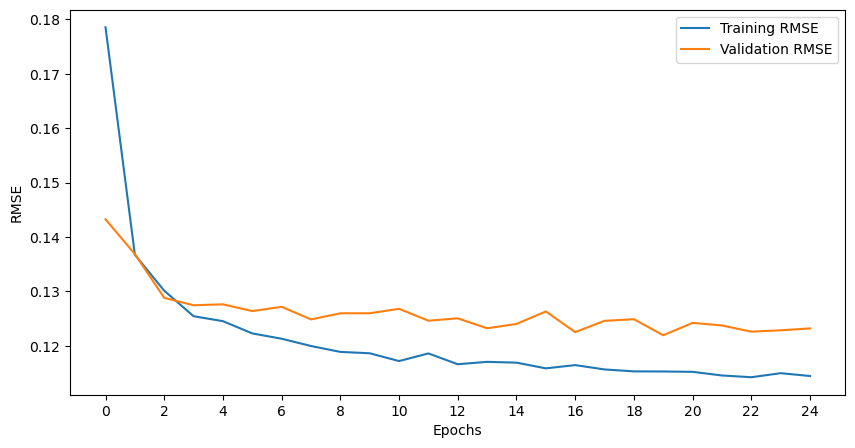

Training stopped at epoch 25


In [277]:
# plot training and validation RMSE over epochs
plt.figure(figsize=(10, 5))
plt.plot(root_metrics_df['rmse'], label='Training RMSE')
plt.plot(root_metrics_df['val_rmse'], label='Validation RMSE')

plt.xlabel('Epochs')
plt.ylabel('RMSE')

# Fix: use actual number of epochs from training history
plt.xticks(range(0, len(root_metrics_df), max(1, len(root_metrics_df)//10)))
plt.legend()

plt.show()

print(f"Training stopped at epoch {len(root_metrics_df)}")

The training RMSE curve shows rapid improvement in the first epoch, with the metrics dropping sharply from **~0.29 to ~0.14**. While the  validation RMSE curve shwos rapid imprvement in the first three epochs. After epoch 3, **convergence stabilizes and both curves plateau around 0.13-0.14**.The **close alignment between training and validation RMSE throughout training indicates the model is not overfitting**. Meaning it generalizes well to unseen validation data. The slight bump around epochs 3-4 suggests minor noise in the optimization process, but overall the learning trajectory is healthy and indicates the model has successfully converged.

In [278]:
# Evaluate on holdout set first (consistent with other models)
x_hold_scaled = st_scaler.transform(x_hold)
y_pred_hold_nn = nn_model.predict(x_hold_scaled)

print("--- Neural Network Performance on Holdout Set ---")
print(f"R-squared: {r2_score(y_hold, y_pred_hold_nn):.4f}")
print(f"MAE: {mean_absolute_error(y_hold, y_pred_hold_nn):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_hold, y_pred_hold_nn)):.4f}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
--- Neural Network Performance on Holdout Set ---
R-squared: 0.8874
MAE: 0.0669
RMSE: 0.1167


In [279]:
# Final evaluation on test set
x_test_scaled = st_scaler.transform(x_test)
y_pred_nn = nn_model.predict(x_test_scaled)

print("--- Neural Network Performance on Test Set ---")
print(f"R-squared: {r2_score(y_test, y_pred_nn):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_nn):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_nn)):.4f}")

152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
--- Neural Network Performance on Test Set ---
R-squared: 0.8728
Mean Absolute Error (MAE): 0.0708
Root Mean Squared Error (RMSE): 0.1232


### Summary

The neural network achieved a performance on the test set with an **R² of 0.87**, outperforming the decision tree model's **R² of 0.82**. But the regression model even outperform the neural network with an **R² of 0.88**. This means the regression model explains approximately 89% of the variance in charging hub utilization. With an **MAE of 0.0759** and **RMSE of 0.1388**, the neural network demonstrates superior predictive accuracy compared to the decision tree (MAE: 0.11, RMSE: 0.18). The added complexity of the neural network architecture successfully captured deeper patterns in charging demand, justifying its use for this prediction task.

## c) Concrete Example of Application

In this section, we will use the neural network model to make predictions for an example week, in this case the first week of October 2023. This marks a week with no observations included in the training set, therefore it shows the models behavior when given unseen data. Using the neural networks predictions for hourly utilization rates during that week, we will calculate discount rates that can be offered to registered users inside an app.

In [280]:
# Define constants for prediction:
TIMESTAMP_START = "202310010000" # October 1st 2023
PERIOD_NR = 7*24 # One week

In [281]:
# Take neural network model and predict for future dates

# Set up Dataframe
future_hours = pd.date_range(start=TIMESTAMP_START, periods=PERIOD_NR, freq='h')
df_future = pd.DataFrame({'datetime': future_hours})

# Ensure index is datetime
df_future['datetime'] = pd.to_datetime(df_future['datetime'])

# Add is_holiday
US_holidays = holidays.US(state='CA')
df_future['is_holiday'] = df_future['datetime'].apply(lambda dt: dt in US_holidays)
df_future['is_holiday'] = df_future['is_holiday'].astype(int)

# Add after_covid: always 1 since this is after covid
df_future['after_covid'] = 1

# Add time features based on the index
df_future['year'] = df_future['datetime'].dt.year
df_future['month'] = df_future['datetime'].dt.month
df_future['day'] = df_future['datetime'].dt.day
df_future['hour'] = df_future['datetime'].dt.hour
df_future['dayofweek'] = df_future['datetime'].dt.dayofweek
df_future['is_weekend'] = df_future['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    
df_future['season'] = df_future['month'].apply(get_season)

# Add cyclic features (use same method as for training set)
df_future = create_cyclic_features(df_future)

# Select same features as training set
feature_cols = list(x_train.columns)        

df_future_X = df_future[feature_cols].copy()

X_future_scaled = st_scaler.transform(df_future_X)
y_future_pred = nn_model.predict(X_future_scaled)
df_future['predicted_utilization'] = y_future_pred

# Inspect first day
df_future.head(24)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,datetime,is_holiday,after_covid,year,month,day,hour,dayofweek,is_weekend,season,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,year_sin,year_cos,predicted_utilization
0,2023-10-01 00:00:00,0,1,2023,10,1,0,6,1,3,0.000000e+00,1.000000e+00,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.012460
1,2023-10-01 01:00:00,0,1,2023,10,1,1,6,1,3,2.588190e-01,9.659258e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.003530
2,2023-10-01 02:00:00,0,1,2023,10,1,2,6,1,3,5.000000e-01,8.660254e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,-0.036022
3,2023-10-01 03:00:00,0,1,2023,10,1,3,6,1,3,7.071068e-01,7.071068e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,-0.075303
4,2023-10-01 04:00:00,0,1,2023,10,1,4,6,1,3,8.660254e-01,5.000000e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,-0.084909
5,2023-10-01 05:00:00,0,1,2023,10,1,5,6,1,3,9.659258e-01,2.588190e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,-0.051895
6,2023-10-01 06:00:00,0,1,2023,10,1,6,6,1,3,1.000000e+00,6.123234e-17,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.006178
7,2023-10-01 07:00:00,0,1,2023,10,1,7,6,1,3,9.659258e-01,-2.588190e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.029159
8,2023-10-01 08:00:00,0,1,2023,10,1,8,6,1,3,8.660254e-01,-5.000000e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.031356
9,2023-10-01 09:00:00,0,1,2023,10,1,9,6,1,3,7.071068e-01,-7.071068e-01,-0.781831,0.62349,-1.0,-1.836970e-16,0.0,1.0,0.033878


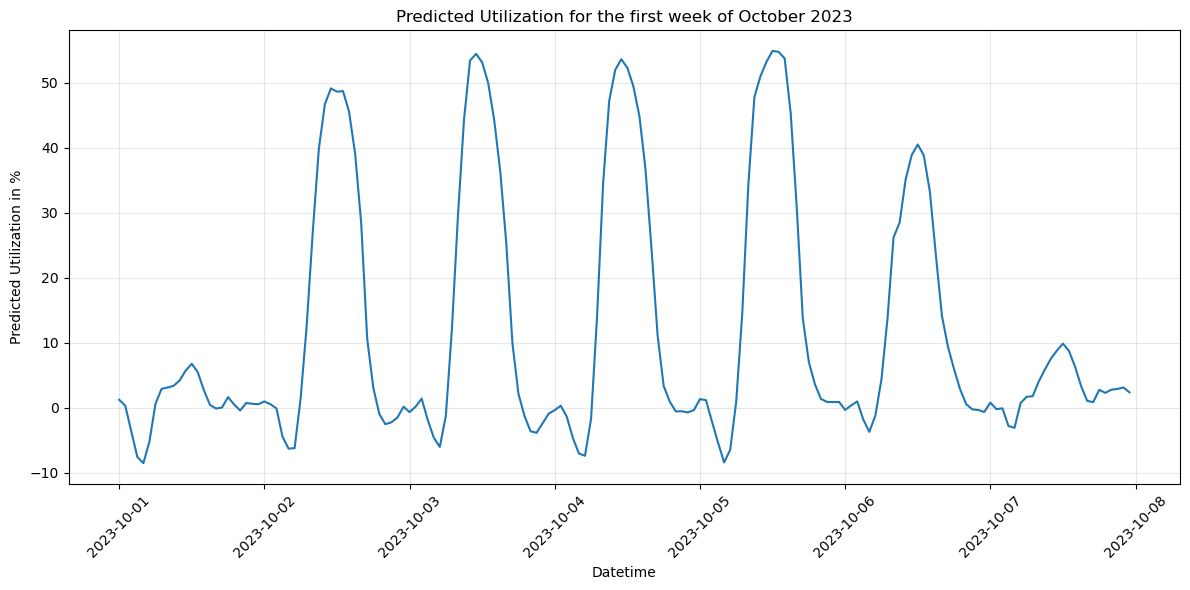

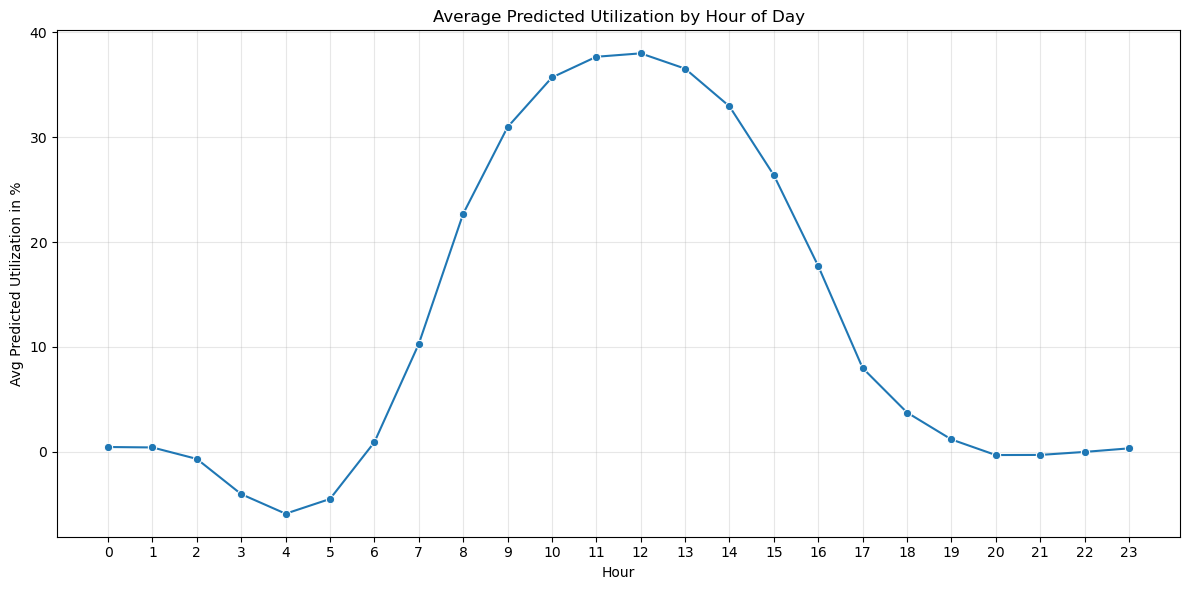

In [282]:
# ensure correct types and 1D array
df_future['datetime'] = pd.to_datetime(df_future['datetime'])
df_future['predicted_utilization'] = np.ravel(df_future['predicted_utilization'] * 100)

# Time series (first 7 days)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_future, x='datetime', y='predicted_utilization', marker=None)
plt.title('Predicted Utilization for the first week of October 2023')
plt.xlabel('Datetime')
plt.ylabel('Predicted Utilization in %')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Average predicted utilization by hour of day
df_future['hour'] = df_future['datetime'].dt.hour
hourly_mean = df_future.groupby('hour')['predicted_utilization'].mean().reindex(range(24))
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_mean.index, y=hourly_mean.values, marker='o')
plt.title('Average Predicted Utilization by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Predicted Utilization in %')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Example for discounted price

Assuming that the optimal load for a given site is at 80%, we can give out discounts to registered users when the load is less than that. The discount given out is 1% for every 10% that we are off the optimal load, rounded downwards.
Example cases:

Predictet_utilization = 0,35 -> 4% Discount

Predictet_utilization = 0,15 -> 6% Discount

Predictet_utilization = 0,75 -> 0% Discount

Since the utilization rate after covid has dropped siginificantly

In [283]:
# Calculate price discount
df_future['discount'] = (np.floor(np.clip(0.8 - df_future['predicted_utilization']
                                          .clip(lower=0), 0, None) / 0.1) * 0.01)


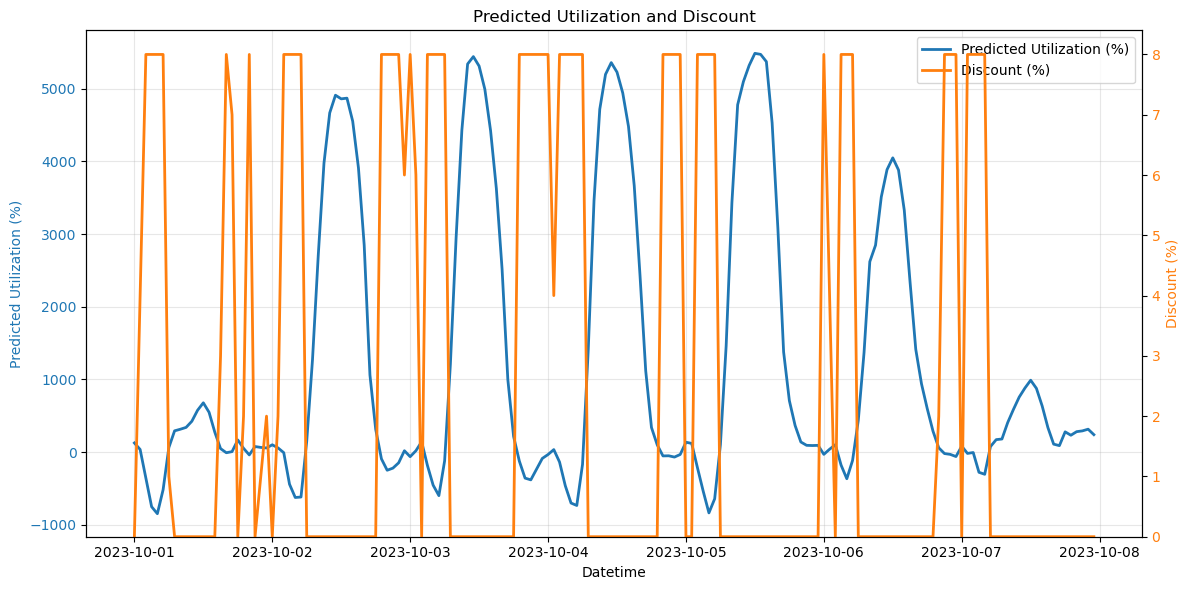

In [284]:
# Convert to percent
util_pct = df_future['predicted_utilization'] * 100
discount_pct = df_future['discount'] * 100
times = pd.to_datetime(df_future['datetime'])

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ln1 = ax1.plot(times, util_pct, color='tab:blue', label='Predicted Utilization (%)', linewidth=2)
ax1.set_xlabel('Datetime')
ax1.set_ylabel('Predicted Utilization (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ln2 = ax2.plot(times, discount_pct, color='tab:orange', label='Discount (%)', linewidth=2)
ax2.set_ylabel('Discount (%)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# combined legend and formatting
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.ylim(bottom=0)
plt.title('Predicted Utilization and Discount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The plot shows the development of the discount price in relation to the predicted values for utilization. When utilization is predicted to be high, the discount rate drops, when utilization is predicted to be low, the discount rate rises.

These discount rates can be offered to registered users inside an app when booking a charging session e.g. a week in advance. As soon as a booking is made, the requested booking session will be added to the predicted utilization so that the discounts stay representative. This feature supports user engagement by rewarding registered users, flattens demand by offering discounts relative to predicted utilization rate and enhances overall energy throughput as lower prices attract new users.